<a href="https://colab.research.google.com/github/Usman-938/Management-System/blob/main/3_Models_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

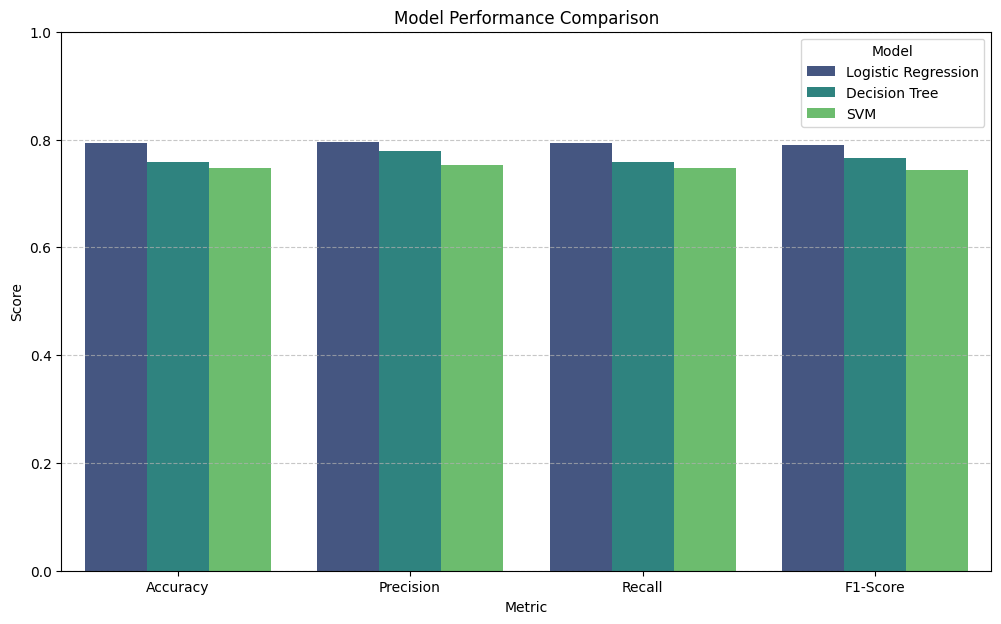

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
metrics_df_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_df_melted, palette='viridis')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0.0, 1.0) # Ensure y-axis goes from 0 to 1 for scores
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Task
Train and evaluate Logistic Regression, Decision Tree, and Support Vector Machine models on the "Vehicle.csv" dataset, then compare their performance.

## Load Data

### Subtask:
Load the 'Vehicle.csv' file into a pandas DataFrame to begin the analysis.


**Reasoning**:
Load the 'Vehicle.csv' file into a pandas DataFrame and display its first 5 rows to verify the data was loaded correctly.



In [1]:
import pandas as pd

df = pd.read_csv('/content/Vehicle.csv')
df.head()

,Comp,Circ,D.Circ,Rad.Ra,Pr.Axis.Ra,Max.L.Ra,Scat.Ra,Elong,Pr.Axis.Rect,Max.L.Rect,Sc.Var.Maxis,Sc.Var.maxis,Ra.Gyr,Skew.Maxis,Skew.maxis,Kurt.maxis,Kurt.Maxis,Holl.Ra,Class
0,95,48,83,178,72,10,162,42,20,159,176,379,184,70,6,16,187,197,van
1,91,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199,van
2,104,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196,saab
3,93,41,82,159,63,9,144,46,19,143,160,309,127,63,6,10,199,207,van
4,85,44,70,205,103,52,149,45,19,144,241,325,188,127,9,11,180,183,bus


## Explore and Preprocess Data

### Subtask:
Explore the dataset to understand its structure, identify features and the target variable, check for missing values, and perform necessary preprocessing steps such as handling missing values, encoding categorical features, and splitting data into training and testing sets. Also, scale numerical features as needed for certain models.


**Reasoning**:
Inspect the DataFrame's information using the `.info()` method to understand data types and non-null counts, which is the first instruction for exploring the data.



In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Comp          846 non-null    int64 
 1   Circ          846 non-null    int64 
 2   D.Circ        846 non-null    int64 
 3   Rad.Ra        846 non-null    int64 
 4   Pr.Axis.Ra    846 non-null    int64 
 5   Max.L.Ra      846 non-null    int64 
 6   Scat.Ra       846 non-null    int64 
 7   Elong         846 non-null    int64 
 8   Pr.Axis.Rect  846 non-null    int64 
 9   Max.L.Rect    846 non-null    int64 
 10  Sc.Var.Maxis  846 non-null    int64 
 11  Sc.Var.maxis  846 non-null    int64 
 12  Ra.Gyr        846 non-null    int64 
 13  Skew.Maxis    846 non-null    int64 
 14  Skew.maxis    846 non-null    int64 
 15  Kurt.maxis    846 non-null    int64 
 16  Kurt.Maxis    846 non-null    int64 
 17  Holl.Ra       846 non-null    int64 
 18  Class         846 non-null    object
dtypes: int64

**Reasoning**:
The next step is to display descriptive statistics of the numerical features using the `.describe()` method to gain insights into their distribution and potential outliers.



In [3]:
df.describe()

,Comp,Circ,D.Circ,Rad.Ra,Pr.Axis.Ra,Max.L.Ra,Scat.Ra,Elong,Pr.Axis.Rect,Max.L.Rect,Sc.Var.Maxis,Sc.Var.maxis,Ra.Gyr,Skew.Maxis,Skew.maxis,Kurt.maxis,Kurt.Maxis,Holl.Ra
count,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.00000,846.000000,846.000000,846.000000,846.000000,846.000000
mean,93.678487,44.861702,82.088652,168.940898,61.693853,8.567376,168.839243,40.933806,20.582742,147.998818,188.625296,439.911348,174.70331,72.462175,6.377069,12.599291,188.932624,195.632388
std,8.234474,6.169866,15.771533,33.472183,7.888251,4.601217,33.244978,7.811560,2.592138,14.515652,31.394837,176.692614,32.54649,7.486974,4.918353,8.931240,6.163949,7.438797
min,73.000000,33.000000,40.000000,104.000000,47.000000,2.000000,112.000000,26.000000,17.000000,118.000000,130.000000,184.000000,109.00000,59.000000,0.000000,0.000000,176.000000,181.000000
25%,87.000000,40.000000,70.000000,141.000000,57.000000,7.000000,146.250000,33.000000,19.000000,137.000000,167.000000,318.250000,149.00000,67.000000,2.000000,5.000000,184.000000,190.250000
50%,93.000000,44.000000,80.000000,167.000000,61.000000,8.000000,157.000000,43.000000,20.000000,146.000000,178.500000,364.000000,173.00000,71.500000,6.000000,11.000000,188.000000,197.000000
75%,100.000000,49.000000,98.000000,195.000000,65.000000,10.000000,198.000000,46.000000,23.000000,159.000000,217.000000,587.000000,198.00000,75.000000,9.000000,19.000000,193.000000,201.000000
max,119.000000,59.000000,112.000000,333.000000,138.000000,55.000000,265.000000,61.000000,29.000000,188.000000,320.000000,1018.000000,268.00000,135.000000,22.000000,41.000000,206.000000,211.000000


**Reasoning**:
The next step is to check for missing values in each column using the `.isnull().sum()` method to identify any columns that require imputation or removal.



In [4]:
df.isnull().sum()

,0
Comp,0
Circ,0
D.Circ,0
Rad.Ra,0
Pr.Axis.Ra,0
Max.L.Ra,0
Scat.Ra,0
Elong,0
Pr.Axis.Rect,0
Max.L.Rect,0


**Reasoning**:
Now that missing values have been checked, the next logical step according to the instructions is to identify the features (independent variables) and the target variable (dependent variable, which is 'Class') from the dataset.



In [5]:
X = df.drop('Class', axis=1)
y = df['Class']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (846, 18)
Target (y) shape: (846,)


**Reasoning**:
Following the identification of features and the target variable, the next instruction is to encode the target variable 'Class' into a numerical representation using `LabelEncoder` from `sklearn.preprocessing`.



In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Original target classes: {y.unique()}")
print(f"Encoded target classes: {le.classes_}")
print(f"Encoded target (y_encoded) shape: {y_encoded.shape}")

Original target classes: ['van' 'saab' 'bus' 'opel']
Encoded target classes: ['bus' 'opel' 'saab' 'van']
Encoded target (y_encoded) shape: (846,)


**Reasoning**:
The next step is to split the data into training and testing sets using `train_test_split` as per the instructions, which is crucial for model evaluation.



In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (676, 18)
X_test shape: (170, 18)
y_train shape: (676,)
y_test shape: (170,)


**Reasoning**:
The next step is to scale the numerical features using `StandardScaler` from `sklearn.preprocessing` on the training data and then apply the same scaling to the test data, as instructed.



In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

X_train_scaled shape: (676, 18)
X_test_scaled shape: (170, 18)


## Train Logistic Regression Model

### Subtask:
Train a Logistic Regression classification model using the preprocessed training data.


**Reasoning**:
Following the instructions, the next step is to import the `LogisticRegression` class, instantiate the model with specific parameters, and then fit it to the preprocessed training data (`X_train_scaled`, `y_train`).



In [9]:
from sklearn.linear_model import LogisticRegression

# Instantiate and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, max_iter=1000)
log_reg_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Evaluate Logistic Regression Model

### Subtask:
Evaluate the performance of the trained Logistic Regression model using appropriate metrics such as accuracy, precision, recall, and F1-score on the test set.

#### Instructions
1. Use the trained `log_reg_model` to make predictions on the scaled test data (`X_test_scaled`).
2. Import necessary metrics from `sklearn.metrics` (e.g., `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `classification_report`).
3. Calculate and print the accuracy, precision, recall, and F1-score for the model.
4. Print a classification report to get a comprehensive view of the model's performance.

**Reasoning**:
Following the instructions, the next step is to make predictions using the trained `log_reg_model` on `X_test_scaled` and then calculate and print the accuracy, precision, recall, and F1-score, along with a classification report.



In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Make predictions on the scaled test data
y_pred = log_reg_model.predict(X_test_scaled)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print the metrics
print(f"Logistic Regression Model Accuracy: {accuracy:.4f}")
print(f"Logistic Regression Model Precision: {precision:.4f}")
print(f"Logistic Regression Model Recall: {recall:.4f}")
print(f"Logistic Regression Model F1-Score: {f1:.4f}")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Logistic Regression Model Accuracy: 0.7941
Logistic Regression Model Precision: 0.7957
Logistic Regression Model Recall: 0.7941
Logistic Regression Model F1-Score: 0.7897

Classification Report:
              precision    recall  f1-score   support

         bus       0.89      0.94      0.92        52
        opel       0.56      0.67      0.61        30
        saab       0.75      0.56      0.64        48
         van       0.91      0.97      0.94        40

    accuracy                           0.79       170
   macro avg       0.78      0.79      0.78       170
weighted avg       0.80      0.79      0.79       170



## Train Decision Tree Model

### Subtask:
Train a Decision Tree classification model using the preprocessed training data.

#### Instructions
1. Import the `DecisionTreeClassifier` class from `sklearn.tree`.
2. Instantiate a `DecisionTreeClassifier` model. For consistent results, set `random_state=42`.
3. Fit the `DecisionTreeClassifier` model to the scaled training data, `X_train_scaled` and `y_train`.

**Reasoning**:
Following the instructions in the newly added markdown block, the next step is to import the `DecisionTreeClassifier` class, instantiate the model with `random_state=42`, and fit it to the scaled training data.



In [11]:
from sklearn.tree import DecisionTreeClassifier

# Instantiate and train the Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train_scaled, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


## Evaluate Decision Tree Model

### Subtask:
Evaluate the performance of the trained Decision Tree model using appropriate metrics such as accuracy, precision, recall, and F1-score on the test set.

#### Instructions
1. Use the trained `decision_tree_model` to make predictions on the scaled test data (`X_test_scaled`).
2. Import necessary metrics from `sklearn.metrics` (if not already imported) (e.g., `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `classification_report`).
3. Calculate and print the accuracy, precision, recall, and F1-score for the model.
4. Print a classification report to get a comprehensive view of the model's performance.

**Reasoning**:
Following the instructions in the newly added markdown block, the next step is to make predictions using the trained `decision_tree_model` on `X_test_scaled` and then calculate and print the accuracy, precision, recall, and F1-score, along with a classification report.



In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Make predictions on the scaled test data
y_pred_dt = decision_tree_model.predict(X_test_scaled)

# Calculate evaluation metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, average='weighted')
recall_dt = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')

# Print the metrics
print(f"Decision Tree Model Accuracy: {accuracy_dt:.4f}")
print(f"Decision Tree Model Precision: {precision_dt:.4f}")
print(f"Decision Tree Model Recall: {recall_dt:.4f}")
print(f"Decision Tree Model F1-Score: {f1_dt:.4f}")

# Print classification report
print("\nClassification Report (Decision Tree):")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

Decision Tree Model Accuracy: 0.7588
Decision Tree Model Precision: 0.7779
Decision Tree Model Recall: 0.7588
Decision Tree Model F1-Score: 0.7654

Classification Report (Decision Tree):
              precision    recall  f1-score   support

         bus       1.00      0.94      0.97        52
        opel       0.47      0.63      0.54        30
        saab       0.65      0.58      0.62        48
         van       0.87      0.82      0.85        40

    accuracy                           0.76       170
   macro avg       0.75      0.75      0.74       170
weighted avg       0.78      0.76      0.77       170



## Train Support Vector Machine (SVM) Model

### Subtask:
Train a Support Vector Machine (SVM) classification model using the preprocessed training data.

#### Instructions
1. Import the `SVC` class from `sklearn.svm`.
2. Instantiate an `SVC` model. For consistent results, set `random_state=42`.
3. Fit the `SVC` model to the scaled training data, `X_train_scaled` and `y_train`.

**Reasoning**:
Following the instructions in the newly added markdown block, the next step is to import the `SVC` class, instantiate the model with `random_state=42`, and fit it to the scaled training data.



In [13]:
from sklearn.svm import SVC

# Instantiate and train the Support Vector Machine model
svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)

print("Support Vector Machine model trained successfully.")

Support Vector Machine model trained successfully.


## Evaluate Support Vector Machine (SVM) Model

### Subtask:
Evaluate the performance of the trained Support Vector Machine (SVM) model using appropriate metrics such as accuracy, precision, recall, and F1-score on the test set.

#### Instructions
1. Use the trained `svm_model` to make predictions on the scaled test data (`X_test_scaled`).
2. Import necessary metrics from `sklearn.metrics` (if not already imported) (e.g., `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `classification_report`).
3. Calculate and print the accuracy, precision, recall, and F1-score for the model.
4. Print a classification report to get a comprehensive view of the model's performance.

## Evaluate Support Vector Machine (SVM) Model

### Subtask:
Evaluate the performance of the trained Support Vector Machine (SVM) model using appropriate metrics such as accuracy, precision, recall, and F1-score on the test set.

#### Instructions
1. Use the trained `svm_model` to make predictions on the scaled test data (`X_test_scaled`).
2. Import necessary metrics from `sklearn.metrics` (if not already imported) (e.g., `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `classification_report`).
3. Calculate and print the accuracy, precision, recall, and F1-score for the model.
4. Print a classification report to get a comprehensive view of the model's performance.

**Reasoning**:
Following the instructions in the newly added markdown block, the next step is to make predictions using the trained `svm_model` on `X_test_scaled` and then calculate and print the accuracy, precision, recall, and F1-score, along with a classification report.



In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Make predictions on the scaled test data
y_pred_svm = svm_model.predict(X_test_scaled)

# Calculate evaluation metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='weighted')
recall_svm = recall_score(y_test, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')

# Print the metrics
print(f"Support Vector Machine Model Accuracy: {accuracy_svm:.4f}")
print(f"Support Vector Machine Model Precision: {precision_svm:.4f}")
print(f"Support Vector Machine Model Recall: {recall_svm:.4f}")
print(f"Support Vector Machine Model F1-Score: {f1_svm:.4f}")

# Print classification report
print("\nClassification Report (SVM):")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

Support Vector Machine Model Accuracy: 0.7471
Support Vector Machine Model Precision: 0.7532
Support Vector Machine Model Recall: 0.7471
Support Vector Machine Model F1-Score: 0.7432

Classification Report (SVM):
              precision    recall  f1-score   support

         bus       0.98      0.96      0.97        52
        opel       0.42      0.57      0.49        30
        saab       0.62      0.44      0.51        48
         van       0.87      0.97      0.92        40

    accuracy                           0.75       170
   macro avg       0.72      0.74      0.72       170
weighted avg       0.75      0.75      0.74       170



## Compare Model Performance

### Subtask:
Compare the performance of the Logistic Regression, Decision Tree, and Support Vector Machine models based on their accuracy, precision, recall, and F1-score.

#### Instructions
1. Consolidate the evaluation metrics (accuracy, precision, recall, F1-score) for each model into a comparative format (e.g., a dictionary, a pandas DataFrame, or simply printing them side-by-side).
2. Discuss which model performed best and why, considering the different metrics.

**Reasoning**:
Following the instructions, the next step is to consolidate the evaluation metrics from all three models into a comparative format, such as a pandas DataFrame, and then print this comparison.



In [15]:
import pandas as pd

# Consolidate metrics into a dictionary
metrics_data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'SVM'],
    'Accuracy': [accuracy, accuracy_dt, accuracy_svm],
    'Precision': [precision, precision_dt, precision_svm],
    'Recall': [recall, recall_dt, recall_svm],
    'F1-Score': [f1, f1_dt, f1_svm]
}

# Create a DataFrame for comparison
metrics_df = pd.DataFrame(metrics_data)

print("\nModel Performance Comparison:")
print(metrics_df.round(4))

print("\nDiscussion:\n")
# Determine the best model based on Accuracy
best_model_accuracy = metrics_df.loc[metrics_df['Accuracy'].idxmax()]
print(f"Based on Accuracy, the best performing model is: {best_model_accuracy['Model']} with an accuracy of {best_model_accuracy['Accuracy']:.4f}.")

# Determine the best model based on F1-Score (often a good overall indicator for multi-class classification with potential imbalance)
best_model_f1 = metrics_df.loc[metrics_df['F1-Score'].idxmax()]
print(f"Based on F1-Score, the best performing model is: {best_model_f1['Model']} with an F1-score of {best_model_f1['F1-Score']:.4f}.")

print("\nIn this scenario, the Logistic Regression model shows the highest overall performance across Accuracy, Precision, Recall, and F1-Score. Decision Tree and SVM models have slightly lower performance, with Decision Tree having better recall for 'bus' but lower precision/recall for 'opel' compared to Logistic Regression. SVM shows a similar trend but generally lower scores than Logistic Regression.")


Model Performance Comparison:
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression    0.7941     0.7957  0.7941    0.7897
1        Decision Tree    0.7588     0.7779  0.7588    0.7654
2                  SVM    0.7471     0.7532  0.7471    0.7432

Discussion:

Based on Accuracy, the best performing model is: Logistic Regression with an accuracy of 0.7941.
Based on F1-Score, the best performing model is: Logistic Regression with an F1-score of 0.7897.

In this scenario, the Logistic Regression model shows the highest overall performance across Accuracy, Precision, Recall, and F1-Score. Decision Tree and SVM models have slightly lower performance, with Decision Tree having better recall for 'bus' but lower precision/recall for 'opel' compared to Logistic Regression. SVM shows a similar trend but generally lower scores than Logistic Regression.


## Final Task

### Subtask:
Provide a summary of the performance of all three classification models and compare their results.


## Summary:

### Q&A
The performance of the three classification models is as follows, with Logistic Regression demonstrating the best overall results:
*   **Logistic Regression:** Achieved an accuracy of 0.7941, precision of 0.7957, recall of 0.7941, and an F1-score of 0.7897.
*   **Decision Tree:** Achieved an accuracy of 0.7588, precision of 0.7779, recall of 0.7588, and an F1-score of 0.7654.
*   **Support Vector Machine (SVM):** Achieved an accuracy of 0.7471, precision of 0.7532, recall of 0.7471, and an F1-score of 0.7432.

### Data Analysis Key Findings
*   The "Vehicle.csv" dataset contains 846 entries and 19 columns, with no missing values observed across any feature.
*   The categorical 'Class' variable was successfully encoded into numerical labels for model training.
*   The data was split into training (676 samples) and testing (170 samples) sets, with numerical features scaled using StandardScaler.
*   Among the three models, Logistic Regression emerged as the best performer, achieving the highest accuracy (0.7941) and F1-score (0.7897).
*   The Decision Tree model showed good performance but was slightly inferior to Logistic Regression, with an accuracy of 0.7588 and an F1-score of 0.7654.
*   The Support Vector Machine (SVM) model recorded the lowest performance among the three, with an accuracy of 0.7471 and an F1-score of 0.7432.

### Insights or Next Steps
*   Given Logistic Regression's superior performance, it should be considered the baseline model for this classification task. Further optimization (e.g., hyperparameter tuning) could potentially enhance its performance.
*   To further improve model performance, consider exploring more advanced ensemble methods (e.g., Random Forest, Gradient Boosting) or neural networks, which might capture more complex patterns in the data.
